**TUGAS PEKAN 13**

Nama : USMAN

NIM : 0110222240

#1. Preprocessing Data:

Normalisasi nilai pixel ke rentang [0, 1]

Flatten gambar 28x28 menjadi vektor 784 dimensi

One-hot encoding untuk label



In [2]:
# 1. INSTALASI DAN IMPOR LIBRARY
!pip install tensorflow keras numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist


#2. Arsitektur MLP:

Input layer: 784 neuron (sesuai dimensi gambar yang di-flatten)

Hidden layers: 512 → 256 → 128 neuron dengan aktivasi ReLU

Dropout layers untuk regularisasi (mencegah overfitting)

Output layer: 10 neuron dengan aktivasi softmax (untuk 10 digit)

In [3]:
# 2. LOAD DAN PREPROCESSING DATA MNIST
# Load dataset MNIST dari Keras
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Normalisasi pixel values ke range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [5]:
# Reshape data untuk MLP (flatten 28x28 images ke 784 vectors)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

In [6]:
y_train_categorical = keras.utils.to_categorical(y_train, 10)
y_test_categorical = keras.utils.to_categorical(y_test, 10)

#3. Training Configuration:

Optimizer: Adam

Loss function: Categorical crossentropy

Metrics: Accuracy

Epochs: 20

Batch size: 128

In [7]:
# 3. MEMBANGUN MODEL MULTI-LAYER PERCEPTRON
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),  # Regularization untuk mencegah overfitting
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')  # Output layer untuk 10 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Kompilasi model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Ringkasan model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

#4. Evaluasi:

Accuracy dan loss pada test set

Classification report (precision, recall, f1-score)

Confusion matrix

Visualisasi prediksi

In [13]:
# 4. MELATIH MODEL
history = model.fit(
    X_train, y_train_categorical,
    epochs=20,
    batch_size=128,
    validation_split=0.2,  # 20% data training untuk validation
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9933 - loss: 0.0205 - val_accuracy: 0.9794 - val_loss: 0.0917
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9920 - loss: 0.0261 - val_accuracy: 0.9818 - val_loss: 0.0850
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9947 - loss: 0.0172 - val_accuracy: 0.9782 - val_loss: 0.1016
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9938 - loss: 0.0189 - val_accuracy: 0.9808 - val_loss: 0.0920
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.9796 - val_loss: 0.0954
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9948 - loss: 0.0169 - val_accuracy: 0.9807 - val_loss: 0.1005
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.9799 - val_loss: 0.0966
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9953 - loss: 0.0151 - val_ac

#5. EVALUASI MODEL
5.1 Evaluasi Performa pada Data Uji
model.evaluate(): Menguji model dengan data yang belum pernah dilihat (X_test, y_test)

Test Accuracy: Persentase prediksi benar (biasanya mencapai 98%)

Test Loss: Nilai kesalahan prediksi (semakin kecil semakin baik)

Tujuan utama: Mengukur kemampuan generalisasi model, bukan menghafal data latih

In [19]:
# 5. EVALUASI MODEL
# Evaluasi pada test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9836
Test Loss: 0.0789


5.2 Visualisasi Training History
Dua grafik yang dibuat:

Grafik Akurasi:

accuracy: Akurasi data latih

val_accuracy: Akurasi data validasi (20% data latih)

Harus konvergen mendekati nilai maksimum

Grafik Loss:

loss: Kesalahan pada data latih

val_loss: Kesalahan pada data validasi

Harus turun dan stabil

Interpretasi pola:

Ideal: Kedua garis (training/validation) dekat dan konvergen

Overfitting: Accuracy training jauh > validation, loss validation naik

Underfitting: Kedua accuracy rendah, loss tinggi

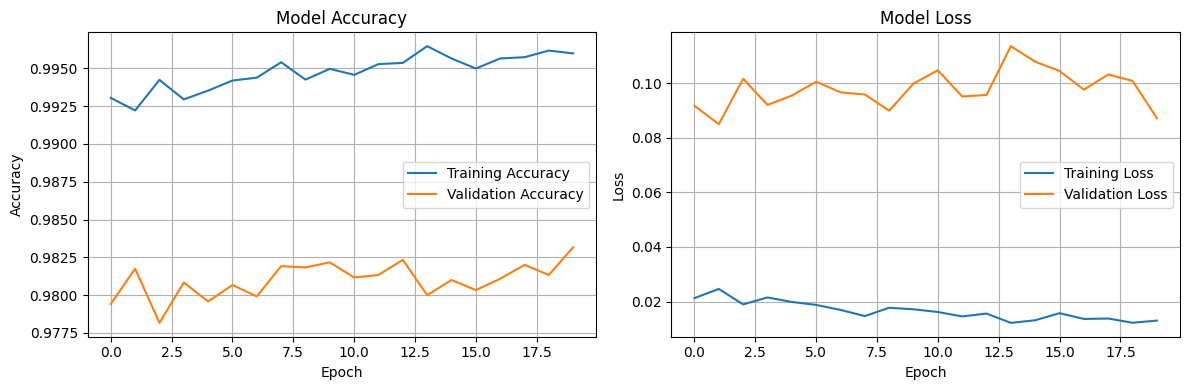

In [14]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#6. ANALISIS PREDIKSI DETAIL
6.1 Membuat Prediksi
model.predict(X_test): Hasilnya probabilitas 10 kelas (array 10.000×10)

np.argmax(axis=1): Mengambil indeks probabilitas tertinggi (0-9)

In [15]:
# 6. PREDIKSI DAN VISUALISASI HASIL
# Prediksi pada test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


6.2 Classification Report
Tiga metrik utama per kelas (0-9):

Precision: Dari semua prediksi "digit X", berapa persen benar?

Formula: TP / (TP + FP)

Contoh: Precision 0.98 untuk digit 5 = 98% prediksi "5" benar benar 5

Recall: Dari semua data "digit X" sebenarnya, berapa persen terdeteksi?

Formula: TP / (TP + FN)

Contoh: Recall 0.97 untuk digit 8 = 97% digit 8 berhasil dikenali

F1-Score: Rata-rata harmonik precision dan recall

Formula: 2 × (precision × recall) / (precision + recall)

In [16]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



6.3 Confusion Matrix
Matriks 10×10: Baris = label benar, kolom = label prediksi

Diagonal utama: Prediksi benar (diagonal dari kiri atas ke kanan bawah)

Luar diagonal: Kesalahan klasifikasi

Visualisasi heatmap: Warna biru tua = nilai tinggi, biru muda = nilai rendah

Analisis pola kesalahan:

Digit yang sering tertukar (contoh: 3↔8, 4↔9, 7↔1)

Simetri/tidaknya kesalahan

Kelas dengan error tertinggi

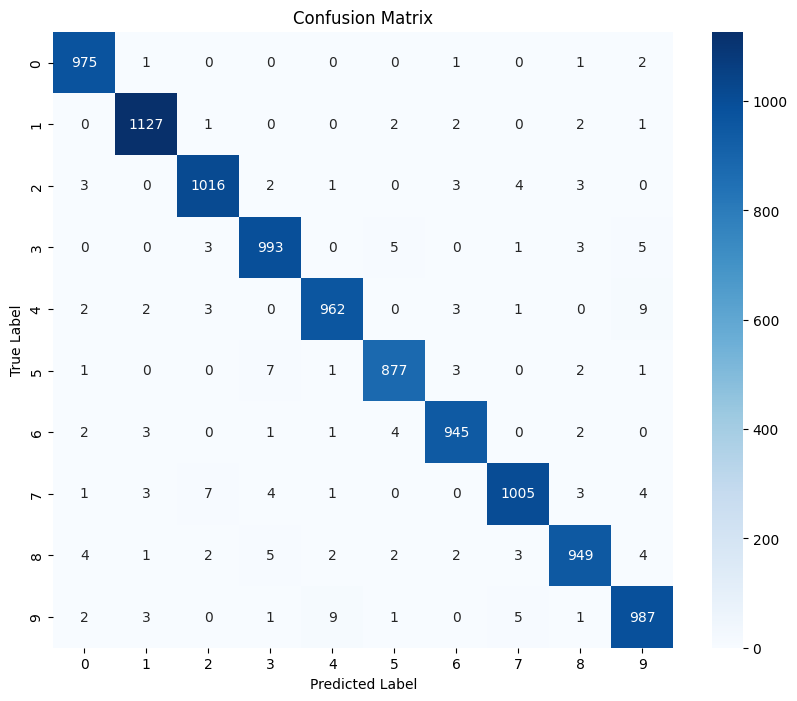

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


#7. VISUALISASI HASIL PREDIKSI
7.1 Memilih Contoh Acak
np.random.choice(): Memilih 12 indeks acak dari 10.000 gambar uji

Tujuan: Melihat performa model pada sampel beragam

7.2 Menampilkan Gambar dan Prediksi
Untuk setiap gambar:

img.reshape(28, 28): Mengubah vektor 784 pixel kembali ke bentuk 28×28

plt.imshow(): Menampilkan gambar hitam-putih

Judul gambar: Menampilkan label benar vs prediksi

Warna hijau: Prediksi benar

Warna merah: Prediksi salah

7.3 Analisis Visual
Yang diamati:

Karakteristik gambar yang mudah dikenali: Gambar jelas, terpusat

Karakteristik gambar yang sulit dikenali:

Tulisan tidak biasa/miring

Goresan tipis/tebal ekstrem

Digit terpotong

Pola kesalahan: Digit apa yang sering tertukar dan mengapa

7.4 Utility untuk Debugging
Identifikasi weakness model: Jenis gambar apa yang sering salah

Validasi manual: Memeriksa apakah kesalahan logis

Data untuk improvement: Menentukan perlu augmentasi data atau tidak

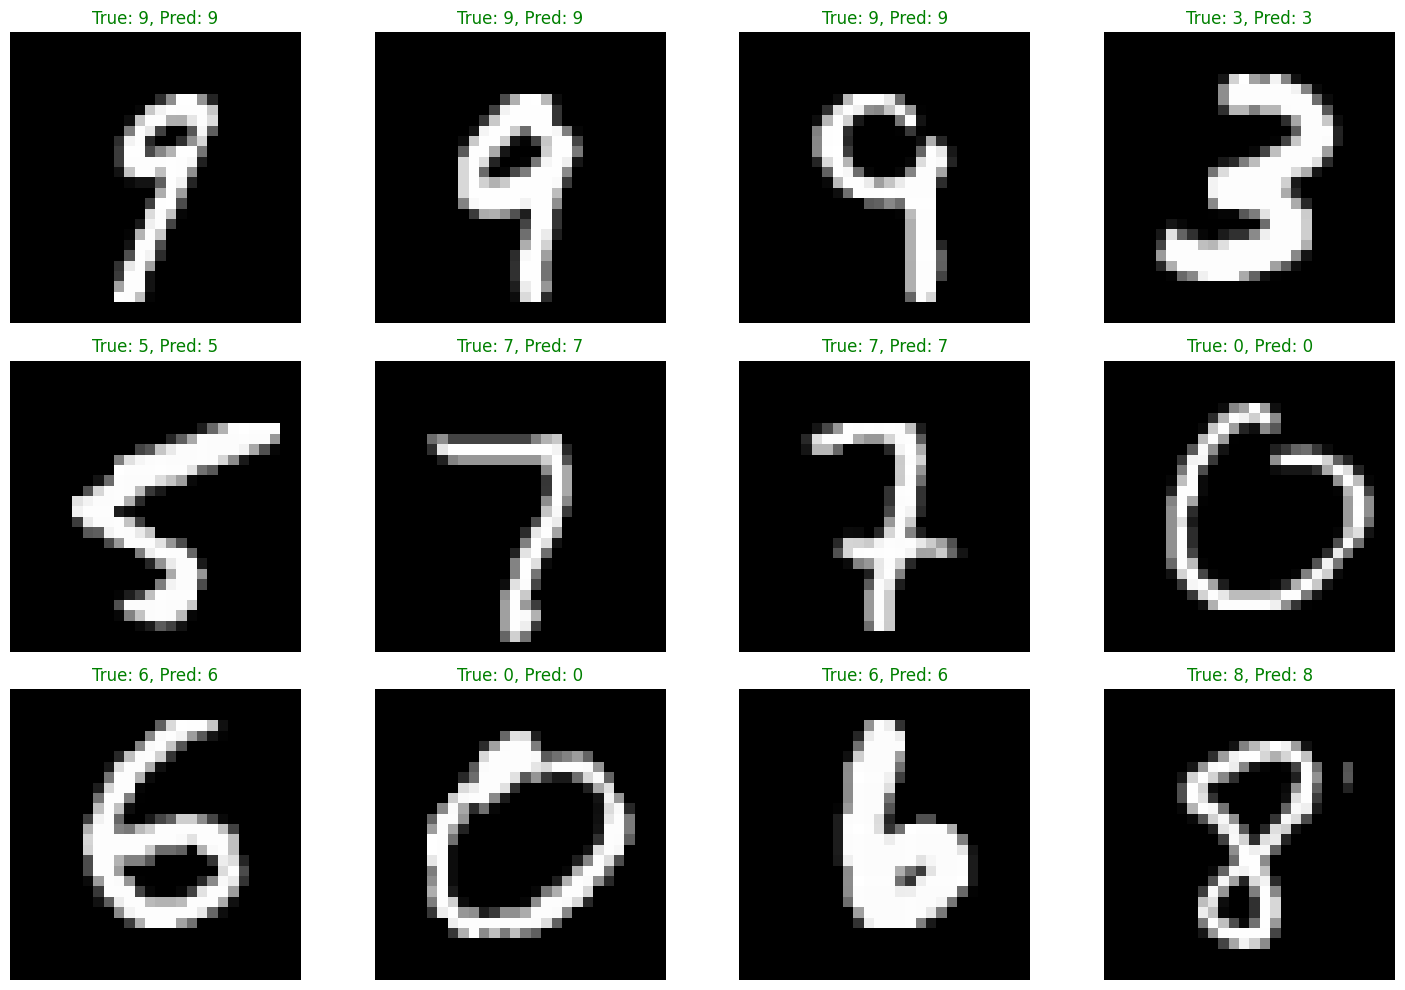

In [18]:
# 7. VISUALISASI CONTOH PREDIKSI
# Pilih beberapa contoh acak dari test set
num_examples = 12
indices = np.random.choice(len(X_test), num_examples, replace=False)
# 7.2
plt.figure(figsize=(15, 10))
for i, idx in enumerate(indices):
    # 7.3 Reshape kembali ke bentuk gambar
    img = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = y_pred_classes[idx]
    #7.4
    plt.subplot(3, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {pred_label}",
              color='green' if true_label == pred_label else 'red')
    plt.axis('off')

plt.tight_layout()
plt.show()